# Declaration of Originality

**School of Informatics & IT**
<br/>**Diploma in Applied Artificial Intelligence**
<br/>**Machine Learning for Developers (CAI2C08)**
<br/>**AY2026/2027 April Semester**
<br/>**Program Codes**

* Student Name:



**Declaration of Originality**
* I am the originator of this work, and I have appropriately acknowledged all other original sources used as my references for this work.
* I understand that Plagiarism is the act of taking and using the whole or any part of another person’s work, including work generated by AI, and presenting it as my own.
* I understand that Plagiarism is an academic offence and if I am found to have committed or abetted the offence of plagiarism in relation to this submitted work, disciplinary action will be enforced.

# Libraries

In [1]:
## Import libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Business Understanding
Goal: 

The goal of this project is to develop a machine learning classification model that predicts whether a patient has heart disease based on their clinical and medical information. Early prediction of heart disease can assist healthcare professionals in identifying high-risk patients and supporting timely medical decision-making.

# 2. Data Understanding

## 2.1 Load dataset

In [2]:
## Read *.csv file into pandas DataFrame

df = pd.read_csv("heart.csv")

df

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0
...,...,...,...,...,...,...,...,...,...,...,...,...
913,45,M,TA,110,264,0,Normal,132,N,1.2,Flat,1
914,68,M,ASY,144,193,1,Normal,141,N,3.4,Flat,1
915,57,M,ASY,130,131,0,Normal,115,Y,1.2,Flat,1
916,57,F,ATA,130,236,0,LVH,174,N,0.0,Flat,1


## 2.2 Summary Statistics

In [3]:
## Understand the type of variable for each column

df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             918 non-null    int64  
 1   Sex             918 non-null    object 
 2   ChestPainType   918 non-null    object 
 3   RestingBP       918 non-null    int64  
 4   Cholesterol     918 non-null    int64  
 5   FastingBS       918 non-null    int64  
 6   RestingECG      918 non-null    object 
 7   MaxHR           918 non-null    int64  
 8   ExerciseAngina  918 non-null    object 
 9   Oldpeak         918 non-null    float64
 10  ST_Slope        918 non-null    object 
 11  HeartDisease    918 non-null    int64  
dtypes: float64(1), int64(6), object(5)
memory usage: 86.2+ KB


In [4]:
## Check for missing data

df.isnull().sum()


Age               0
Sex               0
ChestPainType     0
RestingBP         0
Cholesterol       0
FastingBS         0
RestingECG        0
MaxHR             0
ExerciseAngina    0
Oldpeak           0
ST_Slope          0
HeartDisease      0
dtype: int64

In [5]:
## Describe data distribution

df.describe(include='all')


,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
count,918.000000,918,918,918.000000,918.000000,918.000000,918,918.000000,918,918.000000,918,918.000000
unique,NaN,2,4,NaN,NaN,NaN,3,NaN,2,NaN,3,NaN
top,NaN,M,ASY,NaN,NaN,NaN,Normal,NaN,N,NaN,Flat,NaN
freq,NaN,725,496,NaN,NaN,NaN,552,NaN,547,NaN,460,NaN
mean,53.510893,NaN,NaN,132.396514,198.799564,0.233115,NaN,136.809368,NaN,0.887364,NaN,0.553377
std,9.432617,NaN,NaN,18.514154,109.384145,0.423046,NaN,25.460334,NaN,1.066570,NaN,0.497414
min,28.000000,NaN,NaN,0.000000,0.000000,0.000000,NaN,60.000000,NaN,-2.600000,NaN,0.000000
25%,47.000000,NaN,NaN,120.000000,173.250000,0.000000,NaN,120.000000,NaN,0.000000,NaN,0.000000
50%,54.000000,NaN,NaN,130.000000,223.000000,0.000000,NaN,138.000000,NaN,0.600000,NaN,1.000000
75%,60.000000,NaN,NaN,140.000000,267.000000,0.000000,NaN,156.000000,NaN,1.500000,NaN,1.000000


In [6]:
# Features
features = df.drop(columns=['HeartDisease'], axis=1)

# Target
target = df['HeartDisease']

# Numerical columns
numerical_cols = features.select_dtypes(include=['int64', 'float64']).columns.tolist()

# Categorical columns
categorical_cols = features.select_dtypes(include=['object']).columns.tolist()

print("Features")
print(features.columns.tolist())

print()

print("Numerical Features")
print(numerical_cols)

print()

print("Categorical Features")
print(categorical_cols)

Features
['Age', 'Sex', 'ChestPainType', 'RestingBP', 'Cholesterol', 'FastingBS', 'RestingECG', 'MaxHR', 'ExerciseAngina', 'Oldpeak', 'ST_Slope']

Numerical Features
['Age', 'RestingBP', 'Cholesterol', 'FastingBS', 'MaxHR', 'Oldpeak']

Categorical Features
['Sex', 'ChestPainType', 'RestingECG', 'ExerciseAngina', 'ST_Slope']


In [7]:
for col in categorical_cols:
    print("=" * 40)
    print(df[col].value_counts())
    print()

Sex
M    725
F    193
Name: count, dtype: int64

ChestPainType
ASY    496
NAP    203
ATA    173
TA      46
Name: count, dtype: int64

RestingECG
Normal    552
LVH       188
ST        178
Name: count, dtype: int64

ExerciseAngina
N    547
Y    371
Name: count, dtype: int64

ST_Slope
Flat    460
Up      395
Down     63
Name: count, dtype: int64



In [8]:
for col in categorical_cols:
    print(f"{col}")
    print(f"Unique values: {df[col].nunique()}")
    print(df[col].unique())
    print()


Sex
Unique values: 2
['M' 'F']

ChestPainType
Unique values: 4
['ATA' 'NAP' 'ASY' 'TA']

RestingECG
Unique values: 3
['Normal' 'ST' 'LVH']

ExerciseAngina
Unique values: 2
['N' 'Y']

ST_Slope
Unique values: 3
['Up' 'Flat' 'Down']



The dataset contains five categorical features. All categorical variables have only 2–4 unique categories, which is considered a low cardinality dataset. Therefore, One-Hot Encoding can be safely applied without causing a significant increase in dimensionality or the curse of dimensionality.

In [9]:
duplicates = df.duplicated().sum()

print(f"Number of duplicate rows: {duplicates}")

Number of duplicate rows: 0


The dataset contains no duplicate records. Therefore, no duplicate removal is required before data preprocessing.

## 2.3 Data Visualization

### 2.3.1 Understanding distribution of data

### 2.3.1.1 Understanding distribution of target

In [10]:
df.columns.tolist()

['Age',
 'Sex',
 'ChestPainType',
 'RestingBP',
 'Cholesterol',
 'FastingBS',
 'RestingECG',
 'MaxHR',
 'ExerciseAngina',
 'Oldpeak',
 'ST_Slope',
 'HeartDisease']

C:\Users\phyo5\AppData\Local\Temp\ipykernel_50840\2118829266.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


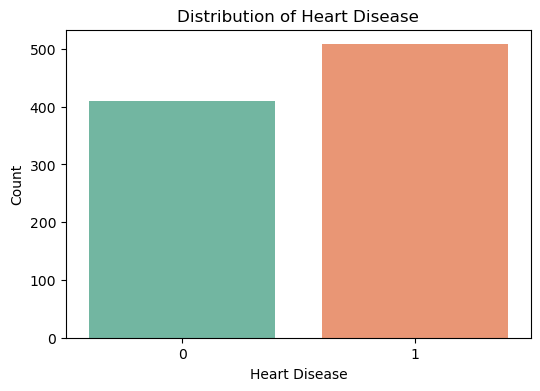

In [11]:
## Understanding distribution of target

import matplotlib.pyplot as plt
import seaborn as sns

# Target variable
y = df["HeartDisease"]

plt.figure(figsize=(6,4))

sns.countplot(
    x=y,
    palette="Set2"
)

plt.title("Distribution of Heart Disease")
plt.xlabel("Heart Disease")
plt.ylabel("Count")

plt.show()



The distribution of the target variable shows that 510 patients (55.6%) have heart disease, while 408 patients (44.4%) do not. 
The classes are reasonably balanced, indicating that classification models can be trained without significant concern for class imbalance.

### 2.3.1.2 Understanding distribution of features

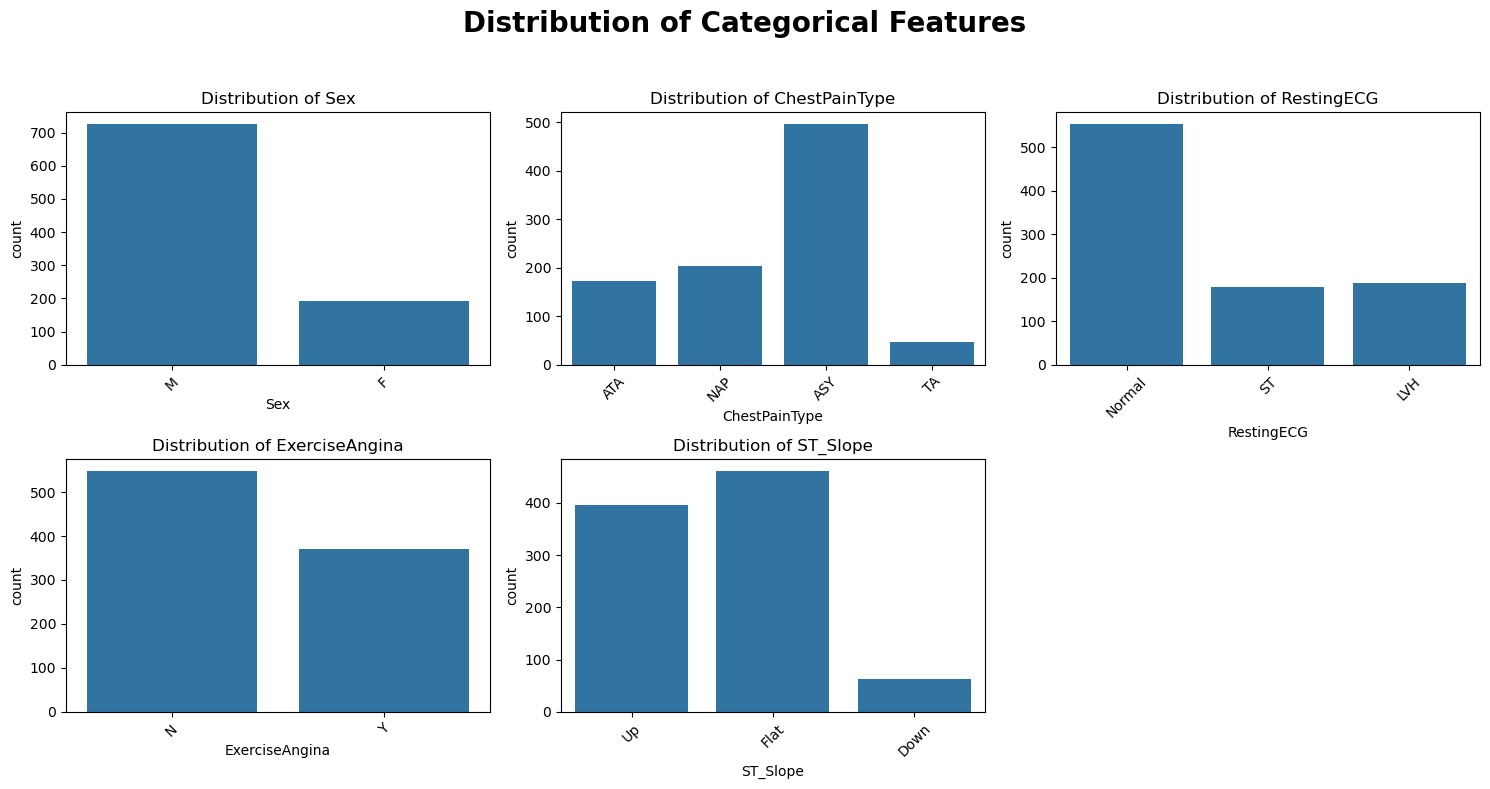

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, col in enumerate(categorical_cols):
    sns.countplot(
        data=df,
        x=col,
        ax=axes[i]
    )
    axes[i].set_title(f"Distribution of {col}")
    axes[i].tick_params(axis='x', rotation=45)

# Hide the unused subplot
axes[-1].set_visible(False)

# Overall title
fig.suptitle(
    "Distribution of Categorical Features",
    fontsize=20,
    fontweight="bold"
)

# Leave space for the title
plt.tight_layout(rect=[0, 0, 1, 0.95])

plt.show()

Sex: The dataset contains substantially more male patients than female patients, indicating a gender imbalance.

ChestPainType: ASY (Asymptomatic) is the most common chest pain type, while TA (Typical Angina) is the least frequent.

RestingECG: Most patients have Normal resting ECG results, whereas ST and LVH occur less frequently.

ExerciseAngina: More patients reported no exercise-induced angina (N) than those who experienced it (Y).

ST_Slope: Flat is the most common ST slope category, followed by Up, while Down is relatively rare.

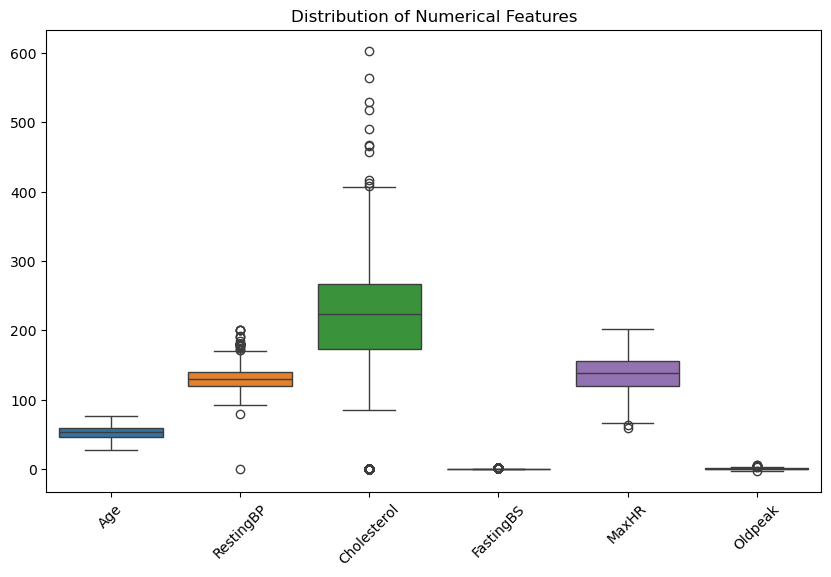

In [13]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

sns.boxplot(data=df[numerical_cols])

plt.xticks(rotation=45)
plt.title("Distribution of Numerical Features")
plt.show()

Age: Most patients are between 47–60 years old, with very few outliers.

RestingBP: Most values lie between 120–140 mmHg, but one value of 0 mmHg is medically impossible and likely represents invalid data.

Cholesterol: Shows the greatest variation, with several extreme values above 400 mg/dL and a maximum exceeding 600 mg/dL. 
Several 0 mg/dL values are also present and are likely invalid.

FastingBS: A binary feature containing only 0 and 1, indicating whether fasting blood sugar exceeds the threshold.

MaxHR: Most patients have a maximum heart rate between 120–160 bpm, with only a few unusually low or high values.

Oldpeak: Most observations are below 2, while a few patients have much higher values (up to 6.2), indicating positive skewness.

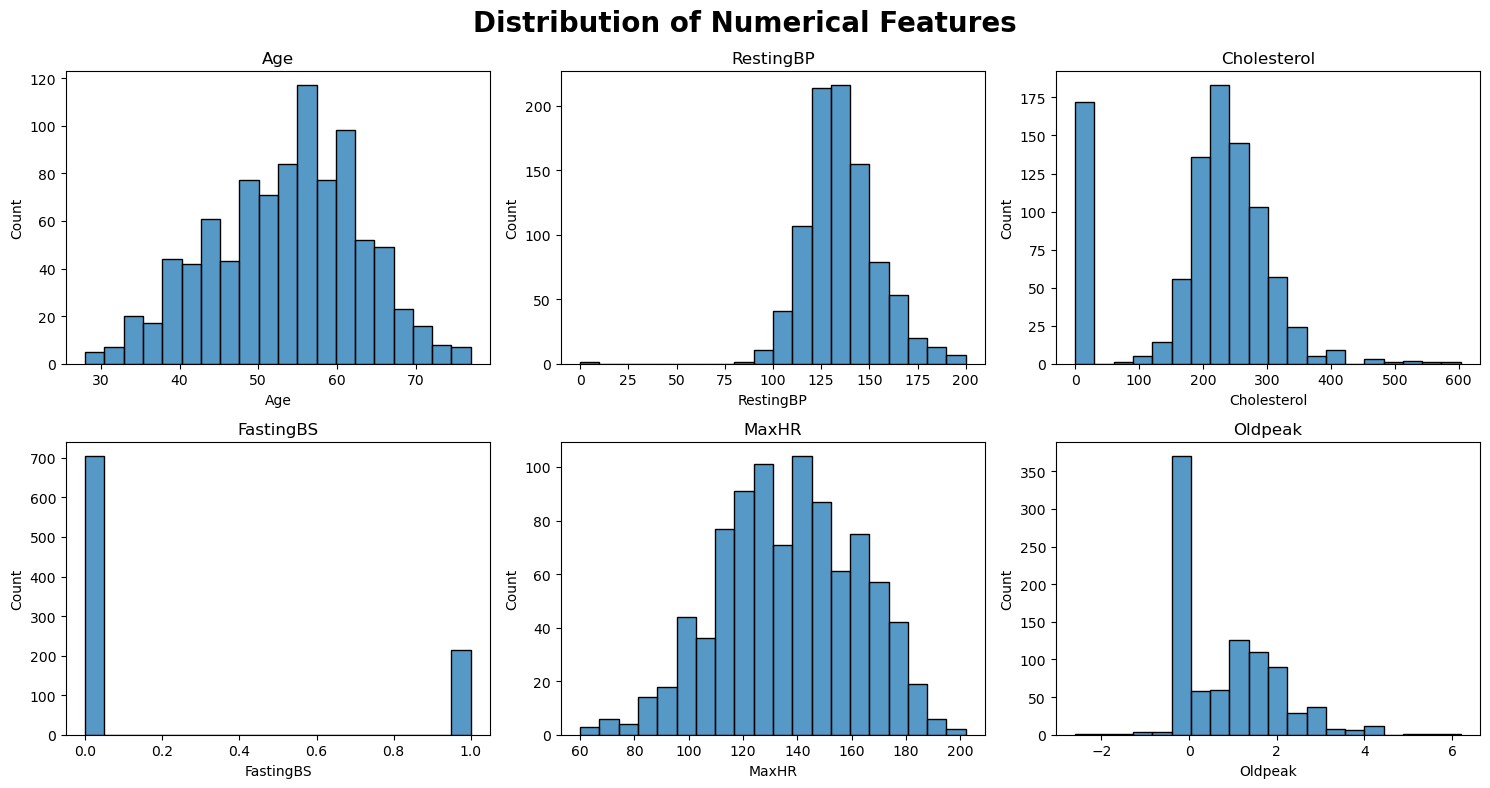

In [14]:
fig, axes = plt.subplots(2, 3, figsize=(15,8))
axes = axes.flatten()

fig.suptitle(
    "Distribution of Numerical Features",
    fontsize=20,
    fontweight="bold"
)


for i, col in enumerate(numerical_cols):
    sns.histplot(
        df[col],
        bins=20,
        ax=axes[i]
    )
    axes[i].set_title(col)

plt.tight_layout()
plt.show()

Age is approximately normally distributed, with most patients aged between 45 and 65.

RestingBP is centered around 120–140 mmHg, with a few high-value outliers.

Cholesterol is right-skewed and contains several extreme outliers. 
The presence of cholesterol values equal to 0 may indicate missing or invalid measurements.

FastingBS is a binary variable, with most patients having a value of 0.

MaxHR is approximately bell-shaped, with most values between 110 and 170 bpm.

Oldpeak is positively skewed, with most patients having values close to 0.

### 2.3.2 Understanding relationship between variables

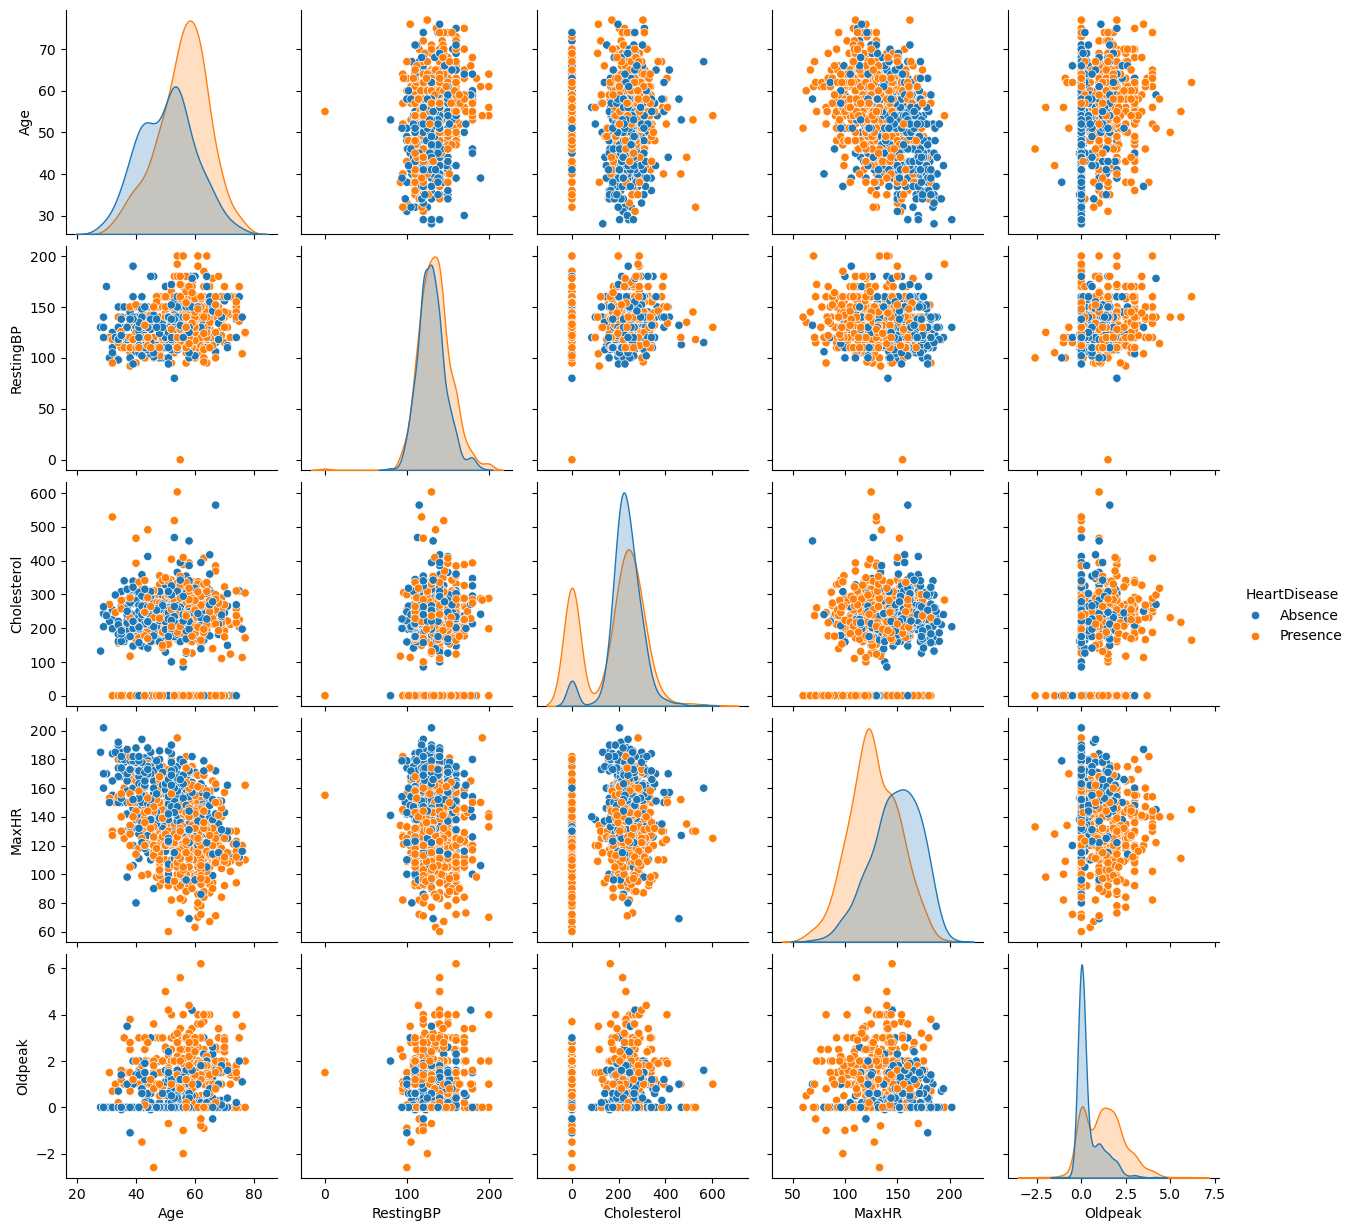

In [15]:
import seaborn as sns
import matplotlib.pyplot as plt

pairplot_df = df.copy()

pairplot_df["HeartDisease"] = pairplot_df["HeartDisease"].map({
    0: "Absence",
    1: "Presence"
})

selected_features = [
    "Age",
    "RestingBP",
    "Cholesterol",
    "MaxHR",
    "Oldpeak",
    "HeartDisease"
]

sns.pairplot(
    pairplot_df[selected_features],
    hue="HeartDisease",
    diag_kind="kde"
)

plt.show()

Age: Patients with heart disease tend to be older than those without heart disease, although there is considerable overlap between the two groups.

MaxHR: Patients with heart disease generally have lower maximum heart rates, while those without heart disease tend 
to achieve higher maximum heart rates. This separation is one of the clearest patterns in the dataset.

Oldpeak: Patients with heart disease generally have higher Oldpeak values, whereas patients without heart disease are concentrated around 0.
 This suggests that Oldpeak is an important predictor of heart disease.

Cholesterol: The distributions of cholesterol values overlap substantially between the two classes, 
indicating that cholesterol alone may not strongly distinguish patients with and without heart disease. 
Several extreme and zero values are also observed.

RestingBP: Both classes show similar distributions of resting blood pressure with no obvious separation, 
suggesting that this feature has weaker discriminative power.

Overall, MaxHR and Oldpeak display the clearest separation between patients with and without heart disease, while Age shows a moderate difference. In contrast, RestingBP and Cholesterol exhibit substantial overlap between the two classes, indicating that they may contribute less predictive information when considered individually.

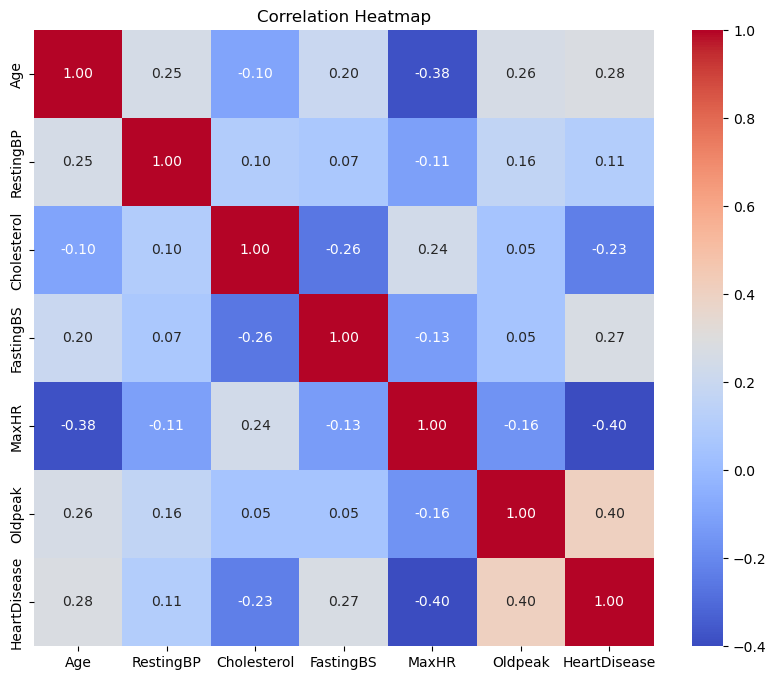

In [16]:
plt.figure(figsize=(10,8))

corr = df[numerical_cols + ['HeartDisease']].corr()

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")
plt.show()

# 3. Data Preparation

## 3.1 Data Cleaning

### 3.1.1 Replacing Invalid Values with Median

In [31]:
## Create a copy of the original dataset

df_clean = df.copy()

In [38]:
invalid_values = pd.DataFrame({
    "Feature": ["RestingBP", "Cholesterol"],
    "Invalid Value": [0, 0],
    "Count": [
        (df["RestingBP"] == 0).sum(),
        (df["Cholesterol"] == 0).sum()
    ]
})

invalid_values

,Feature,Invalid Value,Count
0,RestingBP,0,1
1,Cholesterol,0,172


In [37]:
import numpy as np

# Replace invalid values (0) with the median
df_clean["RestingBP"] = df_clean["RestingBP"].replace(
    0,
    df_clean["RestingBP"].median()
)

df_clean["Cholesterol"] = df_clean["Cholesterol"].replace(
    0,
    df_clean["Cholesterol"].median()
)

valid_values = pd.DataFrame({
    "Feature": ["RestingBP", "Cholesterol"],
    "Invalid Value": [0, 0],
    "Count": [
        (df_clean["RestingBP"] == 0).sum(),
        (df_clean["Cholesterol"] == 0).sum()
    ]
})

valid_values

,Feature,Invalid Value,Count
0,RestingBP,0,0
1,Cholesterol,0,0


During EDA, RestingBP and Cholesterol were found to contain values of 0, 
which are medically unrealistic and therefore treated as invalid data. 
These invalid values were replaced with the median of their respective features. 
The median was chosen instead of the mean because it is less affected 
by extreme values and outliers, making it a more robust measure of central tendency 
for skewed distributions.

### 3.1.2 One-Hot Encoding

In [34]:
# Create a copy of the cleaned dataset
df_encoded = df_clean.copy()

In [ ]:
# Apply One-Hot Encoding
df_encoded = pd.get_dummies(
    df_encoded,
    columns=categorical_cols,
    drop_first=True
)

In [40]:
# Feature and Target Separation
X = df_encoded.drop("HeartDisease", axis=1)
y = df_encoded["HeartDisease"]

In [36]:
df_encoded

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease,Sex_M,ChestPainType_ATA,ChestPainType_NAP,ChestPainType_TA,RestingECG_Normal,RestingECG_ST,ExerciseAngina_Y,ST_Slope_Flat,ST_Slope_Up
0,40,140,289,0,172,0.0,0,True,True,False,False,True,False,False,False,True
1,49,160,180,0,156,1.0,1,False,False,True,False,True,False,False,True,False
2,37,130,283,0,98,0.0,0,True,True,False,False,False,True,False,False,True
3,48,138,214,0,108,1.5,1,False,False,False,False,True,False,True,True,False
4,54,150,195,0,122,0.0,0,True,False,True,False,True,False,False,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
913,45,110,264,0,132,1.2,1,True,False,False,True,True,False,False,True,False
914,68,144,193,1,141,3.4,1,True,False,False,False,True,False,False,True,False
915,57,130,131,0,115,1.2,1,True,False,False,False,True,False,True,True,False
916,57,130,236,0,174,0.0,1,False,True,False,False,False,False,False,True,False


## 3.2 Train-Test Split

In [ ]:
## Split data into train set and test set
## The dataset is split into 70% training data and 30% testing data.

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=2026,
)


# 4. Modelling

### 4.2 Train Model

In [43]:
## Initialise and train model

from sklearn.linear_model import LogisticRegression

logr = LogisticRegression(max_iter=200)

logr.fit(X_train, y_train)


m:\Anaconda\envs\mldp\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 200 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=200).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [44]:
# Predict on the test set

y_pred = logr.predict(X_test)

# 5. Model Evaluation

In [45]:
## Evaluate model

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))


Accuracy: 0.8768115942028986
              precision    recall  f1-score   support

           0       0.91      0.80      0.85       123
           1       0.86      0.93      0.89       153

    accuracy                           0.88       276
   macro avg       0.88      0.87      0.87       276
weighted avg       0.88      0.88      0.88       276

[[ 99  24]
 [ 10 143]]


In [49]:
## New data
new_patient = pd.DataFrame({
    "Age": [55],
    "Sex": ["M"],
    "ChestPainType": ["ASY"],
    "RestingBP": [140],
    "Cholesterol": [250],
    "FastingBS": [1],
    "RestingECG": ["Normal"],
    "MaxHR": [130],
    "ExerciseAngina": ["Y"],
    "Oldpeak": [2.3],
    "ST_Slope": ["Flat"]
})

print(new_patient)

## use One-Hot Encoding
new_patient_encoded = pd.get_dummies(new_patient)

## Match the training columns
new_patient_encoded_preprocessed = new_patient_encoded.reindex(
    columns=X.columns,
    fill_value=0
)

## Predict
prediction = logr.predict(new_patient_encoded_preprocessed)

## Display the prediction result
if prediction[0] == 1:
    print("Prediction: Heart Disease Detected")
else:
    print("Prediction: No Heart Disease")



   Age Sex ChestPainType  RestingBP  Cholesterol  FastingBS RestingECG  MaxHR  \
0   55   M           ASY        140          250          1     Normal    130   

  ExerciseAngina  Oldpeak ST_Slope  
0              Y      2.3     Flat  
Prediction: Heart Disease Detected


## Iterative model development


In [22]:
## Further feature engineering / feature selection